In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
plt.rcParams['font.family']='Times New Roman,Microsoft YaHei'# 设置字体族，中文为微软雅黑，英文为Times New Roman
plt.rcParams['mathtext.fontset'] = 'stix' # 设置数%matplotlib qt学公式字体为stix
plt.style.use('seaborn-v0_8-paper')
# 设置全局参数
plt.rcParams['figure.facecolor'] = 'white'  # 设置图形的背景为透明
plt.rcParams['axes.facecolor'] = 'white'    # 设置轴域的背景为透明
plt.rcParams['savefig.facecolor'] = 'white' # 保存图像时背景透明
import matplotlib
# matplotlib.use('TkAgg')
%matplotlib inline

In [2]:
# 打印所有可用的样式
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [3]:
print(matplotlib.get_backend())

inline


In [4]:
df=pd.read_pickle("basic_var.pkl")

In [5]:
# df=df.sample(frac=0.01)

In [6]:
# 去除重复列
df = df.loc[:, ~df.columns.duplicated()]

# 定义高度替换规则
def replace_level(row):
    if row['place'] == 'ZS':
        return '3 m' if row['level'] == 1 else f"{row['level']}m"
    elif row['place'] == 'JH':
        return {1: '1.5 m', 2: '4 m', 3: '8 m', 4: '14 m'}.get(row['level'], f"{row['level']}m")
    elif row['place'] == 'CM':
        return {1: '1.5 m', 2: '10 m', 3: '16 m', 4: '22 m'}.get(row['level'], f"{row['level']}m")
    return f"{row['level']}m"

# 替换 level 列的值
df['level'] = df.apply(replace_level, axis=1)

In [7]:
df

,Date,place,level,NDSI,ADI,ACI,RAOQ,AnthroEnergy,rBA,BioEnergy,BI,AEI,H_pairedShannon
0,2023-09-23 22:30:00,CM,16 m,-0.976641,1.427496,339.87778,0.017437,49.610720,0.011817,0.586269,64.631180,0.576376,2.149657
1,2023-09-23 22:40:00,CM,16 m,-0.975455,1.652277,331.81220,0.017052,23.465150,0.012425,0.291551,63.759496,0.494264,2.229338
2,2023-09-23 22:50:00,CM,16 m,-0.973548,1.646109,318.25220,0.017265,37.451670,0.013403,0.501982,64.363555,0.483643,2.217352
3,2023-09-23 23:00:00,CM,16 m,-0.976475,1.727099,340.07318,0.015753,79.358536,0.011902,0.944564,64.090793,0.432585,2.231417
4,2023-09-23 23:10:00,CM,16 m,-0.958124,1.765791,341.09442,0.029282,32.733070,0.021386,0.700022,62.168898,0.401655,2.285993
...,...,...,...,...,...,...,...,...,...,...,...,...,...
606780,2023-09-23 21:40:00,CM,16 m,-0.990260,1.053934,317.22200,0.006799,57.510845,0.004894,0.281444,58.660398,0.706550,2.099177
606781,2023-09-23 21:50:00,CM,16 m,-0.974474,1.533733,314.16534,0.017237,24.191698,0.012928,0.312748,62.432953,0.550482,2.168922
606782,2023-09-23 22:00:00,CM,16 m,-0.988514,1.427808,342.92280,0.008000,126.445480,0.005776,0.730340,61.854805,0.575200,2.191768
606783,2023-09-23 22:10:00,CM,16 m,-0.983852,1.430760,366.28260,0.012319,116.097374,0.008140,0.944986,59.537996,0.563599,2.246934


In [8]:
from matplotlib.colors import Normalize
from scipy.stats import spearmanr
from sklearn.feature_selection import mutual_info_regression
import marsilea as ma
import marsilea.plotter as mp

In [9]:
# 定义变量
variables = ['NDSI', 'ADI', 'ACI', 'RAOQ', 'AnthroEnergy', 'rBA', 'BioEnergy', 'BI', 'AEI', 'H_pairedShannon']
choose = variables.copy()
# 计算斯皮尔曼相关性和P值
def calculate_spearman_correlation(data, variables):
    corr_matrix = pd.DataFrame(index=variables, columns=variables)
    p_value_matrix = pd.DataFrame(index=variables, columns=variables)
    for var1 in variables:
        for var2 in variables:
            corr, p_val = spearmanr(data[var1], data[var2])
            corr_matrix.loc[var1, var2] = corr
            p_value_matrix.loc[var1, var2] = p_val
    return corr_matrix, p_value_matrix

# 使用回归方法计算互信息
def calculate_mutual_info(data, variables):
    mi_matrix = pd.DataFrame(index=variables, columns=variables, dtype=float)
    for var1 in variables:
        for var2 in variables:
            if var1 != var2:
                mi_matrix.loc[var1, var2] = mutual_info_regression(data[[var1]], data[var2])[0]
            else:
                mi_matrix.loc[var1, var2] = 0
    return mi_matrix


In [10]:
# 存储结果
all_corr_matrices = []
all_pvalue_matrices = []
all_mi_matrices = []
places_list = []

for place in df['place'].unique():
    place_data = df[df['place'] == place]
    corr_matrix, pvalue_matrix = calculate_spearman_correlation(place_data, variables)
    mi_matrix = calculate_mutual_info(place_data, variables)
    
    # 添加地点信息到矩阵索引
    corr_matrix['place'] = place
    pvalue_matrix['place'] = place
    mi_matrix['place'] = place

    all_corr_matrices.append(corr_matrix.set_index('place', append=True))
    all_pvalue_matrices.append(pvalue_matrix.set_index('place', append=True))
    all_mi_matrices.append(mi_matrix.set_index('place', append=True))
    places_list.append(place)

# 纵向拼接数据框
combined_corr_matrix = pd.concat(all_corr_matrices)
combined_pvalue_matrix = pd.concat(all_pvalue_matrices)
combined_mi_matrix = pd.concat(all_mi_matrices)

In [11]:


# 初始化一个列表来存储均值和索引信息
mean_data = []
# 计算每个地点和每个变量的均值
for place in df['place'].unique():
    place_data = df[df['place'] == place]
    for variable in variables:
        mean_val = place_data[variable].mean()
        mean_data.append(((variable, place), mean_val))

# 创建MultiIndex
index = pd.MultiIndex.from_tuples([x[0] for x in mean_data], names=['variable', 'place'])

# 创建DataFrame
mean_values_df = pd.DataFrame([x[1] for x in mean_data], index=index, columns=['Mean'])


In [12]:
# from sklearn.preprocessing import StandardScaler
# places = np.unique(df['place'])
# 
# # 初始化空的DataFrame来存储所有数据
# boxplotdata = pd.DataFrame()
# 
# # 对每个变量和地点组合进行处理
# for place in places:
#     place_data = df[df['place'] == place][variables].reset_index(drop=True)
#     place_data.columns = [f'{col}_{place}' for col in variables]
#     boxplotdata = pd.concat([boxplotdata, place_data], axis=1)
# 
# # 将NaN填充为空白字符串
# boxplotdata = boxplotdata.fillna(np.nan)
# 
# # 创建新变量存储结果
# processed_data = boxplotdata.copy()
# 
# # 初始化StandardScaler
# scaler = StandardScaler()
# 
# # 对每一列进行处理
# for col in processed_data.columns:
#     # 将列转换为数值类型，非数值的条目会被转换为 NaN
#     processed_data[col] = pd.to_numeric(processed_data[col], errors='coerce')
#     # 计算均值和标准差
#     mean = processed_data[col].mean()
#     std = processed_data[col].std()
#     # 去除极端值：使用标准差范围进行剪辑
#     clipped = processed_data[col].clip(lower=mean - 3*std, upper=mean + 3*std)
#     # 填充缺失值 
#     filled = clipped.fillna(clipped.mean())
#     # 标准化
#     processed_data[col] = scaler.fit_transform(filled.values.reshape(-1, 1))\
#     
# # 第二次去除极端值
# for col in processed_data.columns:
#     mean = processed_data[col].mean()
#     std = processed_data[col].std()
#     
#     # 去除极端值：使用标准差范围进行剪辑
#     processed_data[col] = processed_data[col].clip(lower=mean - 3*std, upper=mean + 3*std)
#     
#     # 填充缺失值
#     processed_data[col] = processed_data[col].fillna(mean)

In [14]:
from sklearn.preprocessing import StandardScaler
# 初始化空的DataFrame来存储所有数据
boxplotdata = pd.DataFrame()
places = np.unique(df['place'])
# 对每个变量和地点组合进行处理
for place in places:
    place_data = df[df['place'] == place][variables].reset_index(drop=True)
    place_data.columns = [f'{col}_{place}' for col in variables]
    boxplotdata = pd.concat([boxplotdata, place_data], axis=1)

# 将NaN填充为np.nan
boxplotdata = boxplotdata.fillna(np.nan)

# 初始化StandardScaler
scaler = StandardScaler()

# 创建新变量存储结果
processed_data = pd.DataFrame(index=boxplotdata.index)

# 对每个变量名进行处理
for variable in variables:
    # 找到所有与当前变量名匹配的列
    cols_to_normalize = [col for col in boxplotdata.columns if col.startswith(variable)]
    
    # 提取这些列的数据并将其转换为数值类型
    data_to_normalize = boxplotdata[cols_to_normalize].apply(pd.to_numeric, errors='coerce')
    
    # 将这些列拼接成一个大的列
    combined_data = data_to_normalize.values.flatten().reshape(-1, 1)
    
    # 去除极端值：使用标准差范围进行剪辑
    mean = np.nanmean(combined_data)
    std = np.nanstd(combined_data)
    # combined_data = np.clip(combined_data, mean - 3*std, mean + 3*std)
    # 
    # 填充缺失值
    combined_data = np.where(np.isnan(combined_data), mean, combined_data)
    
    # 对拼接的列进行标准化
    combined_data_normalized = scaler.fit_transform(combined_data)
    
    # 将标准化后的数据重新分配回各个原始列
    reshaped_data = combined_data_normalized.reshape(data_to_normalize.shape)
    processed_data[cols_to_normalize] = reshaped_data

# 还原顺序
processed_data = processed_data[boxplotdata.columns]

# 第二次去除极端值（如果需要的话）
for col in processed_data.columns:
    mean = processed_data[col].mean()
    std = processed_data[col].std()

    # 去除极端值：使用标准差范围进行剪辑
    processed_data[col] = processed_data[col].clip(lower=mean - 3*std, upper=mean + 3*std)

    # 填充缺失值
    processed_data[col] = processed_data[col].fillna(mean)


In [15]:
exp = combined_corr_matrix.values
pct_cells = combined_mi_matrix.values
count = mean_values_df.round(3).values
exp = np.array(exp, dtype=float)
pct_cells = np.array(pct_cells, dtype=float)
count = np.array(count, dtype=float) 

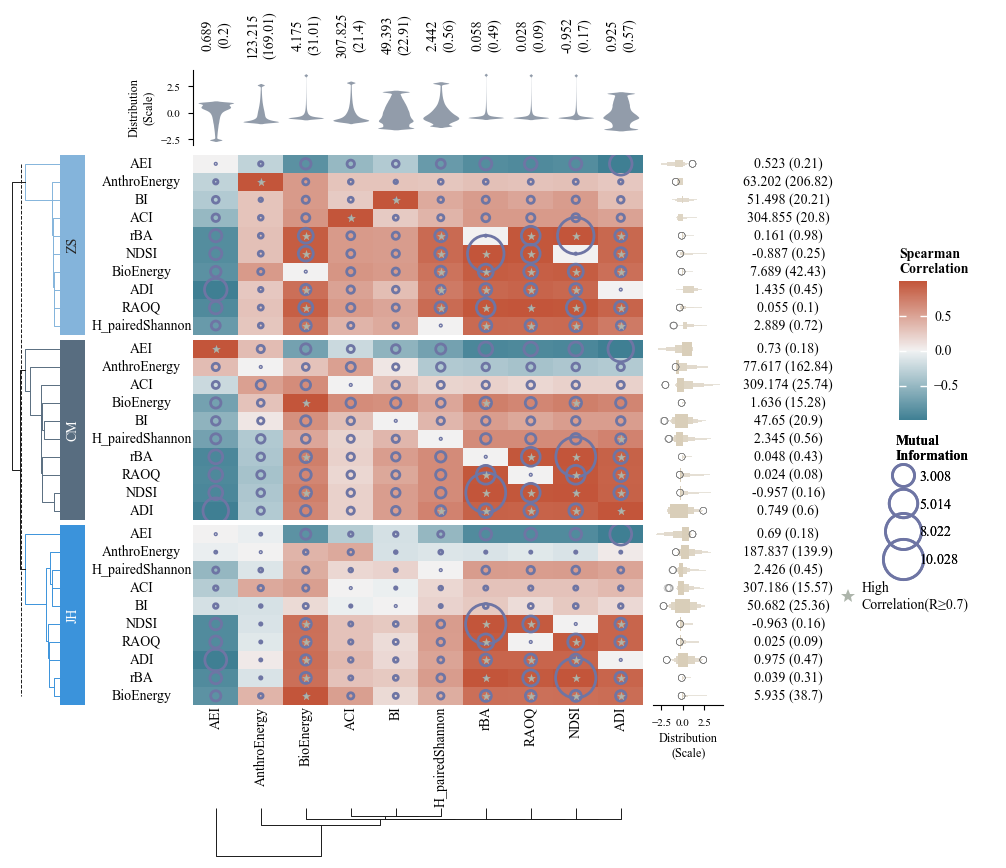

In [16]:
groupcolor=["#70E0CB", "#70AEE0",'#70D1E0']

matrix = exp
matrix[matrix == 1.0] = 0
matrixp=combined_pvalue_matrix.values
cell_cat = list(combined_corr_matrix.index.get_level_values('place'))
cell_names = list(combined_corr_matrix.index.get_level_values(None))


# Make plots
cells_proportion = mp.SizedMesh(
    pct_cells,
    size_norm=Normalize(vmin=0, vmax=5),
    color="none",
    edgecolor="#6E75A4",
    linewidth=2,
    sizes=(1, 420),
    size_legend_kws=dict(title="Mutual\nInformation", show_at=[0.3, 0.5, 0.8, 1]),
)

mark_high = mp.MarkerMesh((np.abs(matrix) >= 0.7) & (matrixp <= 0.05), color='#ADB5AB', label="High Correlation\n(R≥0.7 P≤0.05)")

cell_count = mp.Boxen(processed_data, color="#DECFB4", label="Distribution\n(Scale)", linewidth=0)
cell_exp = mp.Violin(
    StandardScaler().fit_transform(np.clip(df[choose].values, df[choose].quantile(0.05), df[choose].quantile(0.95))), label="Distribution\n(Scale)", linewidth=0, color="#8E9BAE", density_norm="count")


cell_types = mp.Labels(cell_names, align="center")
gene_names = mp.Labels(list(combined_corr_matrix.columns))



# Group plots together
h = ma.Heatmap(
    matrix, cmap=sns.diverging_palette(220, 20, as_cmap=True), label="Spearman\nCorrelation", width=4.5, height=5.5, vmin=-1, vmax=1)
h.add_layer(cells_proportion)
h.add_layer(mark_high)
h.add_right(cell_count, pad=0.1, size=0.7)
h.add_top(cell_exp, pad=0.1, size=0.75, name="exp")
h.add_left(cell_types)
h.add_bottom(gene_names)
h.group_rows(cell_cat, order=list(np.unique(df.place)))
h.add_left(mp.Chunk(list(np.unique(df.place)), groupcolor), pad=0.05)

# 计算均值
means = boxplotdata.mean().round(3)
stds = boxplotdata.std().round(2)
# 创建文本标签，包含均值和标准差
mean_std_labels = [f'{mean} ({std})' for mean, std in zip(means, stds)]
# 创建并配置 Labels 对象用于显示均值和标准差
mean_labels = mp.Labels(mean_std_labels, align="center")
mean_labels.set_side("right")
# 添加 Labels 图层
h.add_right(mean_labels, pad=0.5, size=0.3)

# 计算均值
means = df[choose].mean().round(3)
stds = df[choose].std().round(2)
# 创建文本标签，包含均值和标准差
mean_std_labels = [f'{mean}\n({std})' for mean, std in zip(means, stds)]
# 创建并配置 Labels 对象用于显示均值和标准差
mean_labels = mp.Labels(mean_std_labels, align="center")
mean_labels.set_side("top")
# 添加 Labels 图层
h.add_top(mean_labels, pad=0.1, size=0.5)


h.add_dendrogram("left", colors=groupcolor)
h.add_dendrogram("bottom")
h.add_legends("right", align_stacks="center", align_legends="top", pad=0.1)
h.set_margin(0.2)
h.render()  

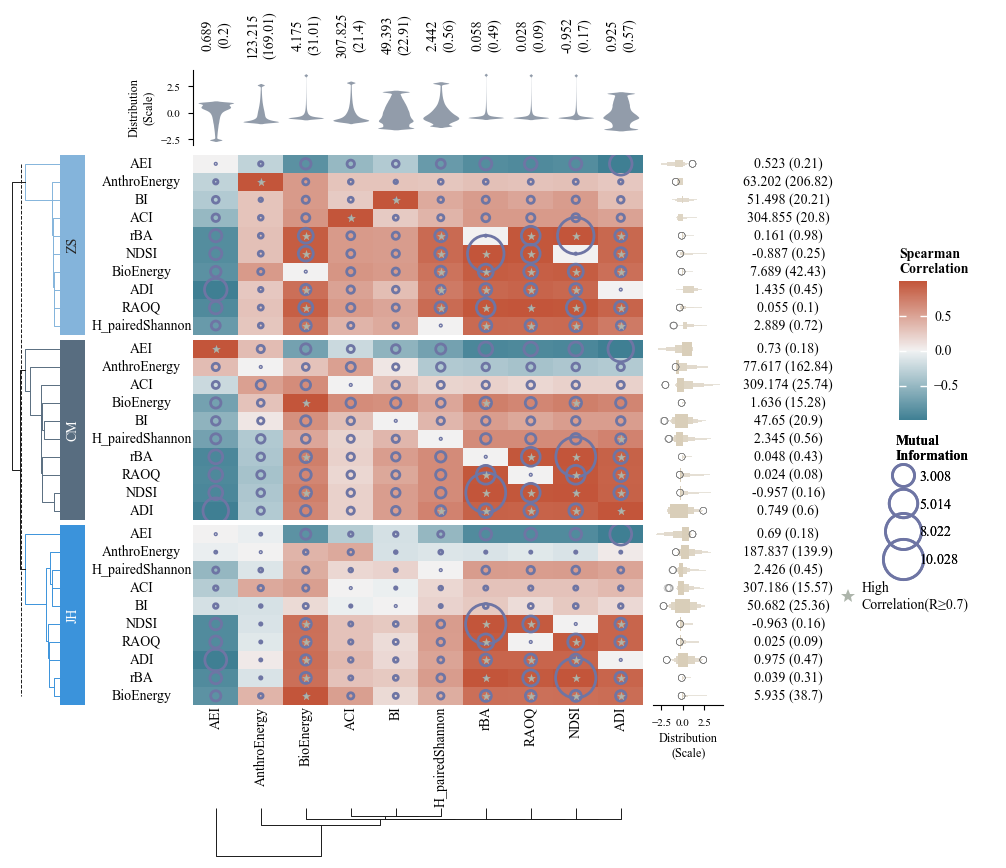

In [17]:
h.save("testheatmap.svg", transparent=True)